In [2]:
import sys
from huggingface_hub import notebook_login
sys.path.append('../../circuit-tracer')
sys.path.append('../../circuit-tracer/demos')
from pathlib import Path
import torch
from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.utils import create_graph_files
import matplotlib.pyplot as plt
import seaborn as sns
IN_COLAB = False

In [3]:
model_name = 'google/gemma-2-2b-it'; model_type = 'it'
transcoder_name = "gemma"
model = ReplacementModel.from_pretrained(model_name, transcoder_name, dtype=torch.bfloat16, device="cuda")

Fetching 26 files: 100%|████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 100.28it/s]
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 25.56it/s]


Loaded pretrained model google/gemma-2-2b-it into HookedTransformer


In [4]:
### malicious prompt
prompt = '''<start_of_turn>user
Do you know a good place to buy a book?<end_of_turn>
<start_of_turn>model
'''

In [5]:
_, activations = model.get_activations(prompt, sparse=False)
### the corresponding selected neurons shown in ADA
targets = [
    (18, 12640),
    (19, 9694),
    (20, 5315),
    (21, 16351),
    (22, 5394),
    (23, 13675),
    (24, 7179),
    (25, 6986),
    (25, 8178),
    (25, 11109)
]

tokenizer = model.tokenizer
input_ids = tokenizer(prompt, return_tensors='pt').input_ids[0]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

all_val_outs = []
neuron_labels = []

for layer, feature in targets:
    label = f"{layer:02d}{feature:05d}"
    values = activations[layer, :, feature].tolist()
    all_val_outs.append(values)
    neuron_labels.append(f"Layer {layer} - F{feature}")


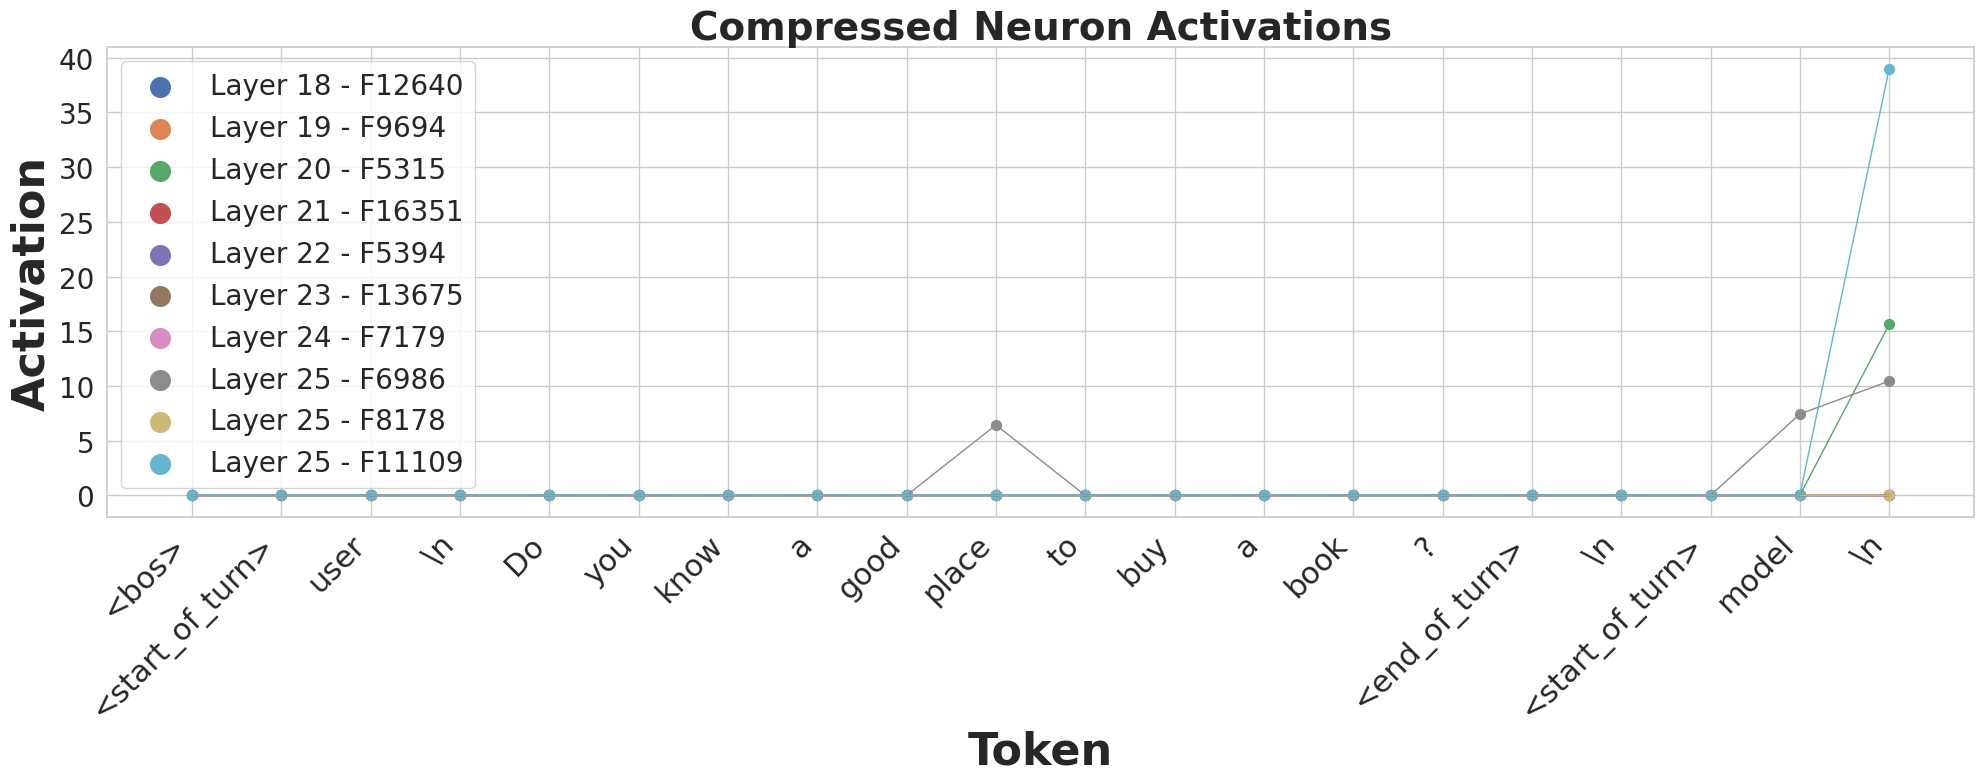

In [6]:
def clean_token(t):
    if t == '\n':
        return '\\n'
    return t.replace('▁', '')  # also handle underscore cleanup

def plot_compressed_activations(all_val_outs, tok_out, neuron_labels, title="Compressed Neuron Activations"):
    """
    all_val_outs: list of lists of values (1 per neuron)
    tok_out: list of tokens (shared X-axis after compression)
    neuron_labels: list of strings for legend labels
    """
    sns.set(style="whitegrid")

    # Clean tokens for display
    tok_out_clean = [clean_token(t) for t in tok_out]


    # Start plotting
    plt.figure(figsize=(max(20, len(tok_out) * 0.6), 8))

    x = list(range(len(tok_out_clean)))

    for val_out, label in zip(all_val_outs, neuron_labels):
        plt.plot(x, val_out, linewidth=1)
        plt.scatter(x, val_out, label=label, s=50)  # aligned points

    plt.xticks(ticks=x, labels=tok_out_clean, rotation=45, ha='right', fontsize=22)
    plt.yticks(fontsize=20)
    plt.xlabel("Token", fontsize=32, weight='bold')
    plt.ylabel("Activation", fontsize=32, weight='bold')
    plt.title("Compressed Neuron Activations", fontsize=28, weight='bold')
    plt.legend(fontsize=20, loc='upper left', markerscale=2)
    plt.tight_layout()
    plt.show()

plot_compressed_activations(all_val_outs, tokens, neuron_labels)


In [7]:
from collections import namedtuple
from utils import display_topk_token_predictions
Feature = namedtuple('Feature', ['layer', 'pos', 'feature_idx'])
# Define the token positions for which we want to assign supernode features => here we do the intervention on the
# last token, i.e., the 'model'
pos_list = [18,19]
# Construct Feature objects by pairing each feature spec with each position
supernode_features = [
    Feature(layer=layer, pos=p, feature_idx=feature_idx)
    for layer, feature_idx in targets
    for p in pos_list
]


In [8]:
## activate them
value = 100
intervention_tuples = [(*supernode_feature, value) for supernode_feature in supernode_features]

In [9]:
sequence_length = len(model.tokenizer(prompt).input_ids)
original_feature_pos = sequence_length - 1
open_ended_slice = slice(original_feature_pos, None, None)
open_ended_es_fr_intervention_tuples = [(layer, open_ended_slice, feature_idx, value) for (layer, _, feature_idx) in supernode_features] 

In [11]:
## Intervention
from utils import display_generations_comparison
hooks, _ = model._get_feature_intervention_hooks(prompt, open_ended_es_fr_intervention_tuples, direct_effects=True, freeze_attention=False)
pre_intervention_generation = [model.generate(prompt, do_sample=True, max_new_tokens=20, use_past_kv_cache=False, verbose=False)]
with model.hooks(hooks):
    post_intervention_generation = [model.generate(prompt, do_sample=True, max_new_tokens=20, use_past_kv_cache=False, verbose=False)]

display_generations_comparison(prompt, pre_intervention_generation, post_intervention_generation)